## Getting the Dataset

This lab uses the IMDB Movie Reviews dataset, built directly into Keras — no download or upload needed. Reviews are already converted to sequences of word-index integers.

In [1]:
from tensorflow import keras
import numpy as np

vocab_size = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

print("Training reviews:", len(X_train))
print("Test reviews:", len(X_test))
print("First review (word indices):", X_train[0][:20])
print("First review's label (0=negative, 1=positive):", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training reviews: 25000
Test reviews: 25000
First review (word indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First review's label (0=negative, 1=positive): 1


## Decoding a Review Back to Words

Just to see what the data actually represents, here's how to turn word indices back into readable text.

In [2]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print(decode_review(X_train[0]))
print("\nLabel:", "Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these c

## Preparing the Data: Padding Sequences

Reviews vary in length, but the network needs a fixed input size. We'll pad/truncate every review to 200 words.

In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 200
X_train_padded = pad_sequences(X_train, maxlen=maxlen)
X_test_padded = pad_sequences(X_test, maxlen=maxlen)

print("Padded shape:", X_train_padded.shape)
print("Example padded review:", X_train_padded[0][:20], "...")

Padded shape: (25000, 200)
Example padded review: [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2] ...


## Example 1: Building an LSTM Model

In [4]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

## Example 2: Compiling & Training

To keep training time reasonable, we'll train on a subset first.

In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_padded[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.6681 - loss: 0.5941 - val_accuracy: 0.8100 - val_loss: 0.4314
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.8594 - loss: 0.3398 - val_accuracy: 0.8375 - val_loss: 0.3718
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.9231 - loss: 0.2160 - val_accuracy: 0.8480 - val_loss: 0.3668
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9507 - loss: 0.1479 - val_accuracy: 0.8485 - val_loss: 0.4073
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.9645 - loss: 0.1086 - val_accuracy: 0.8430 - val_loss: 0.4343


## Example 3: Visualizing Training Progress

Ellipsis

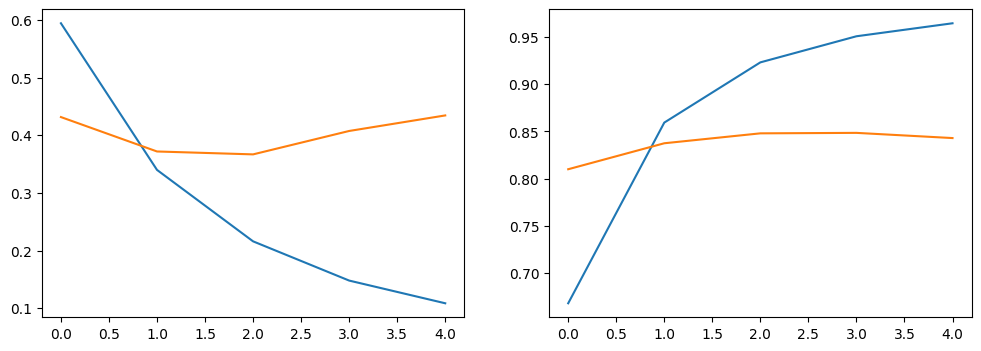

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
...

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
...

## Example 4: Evaluating and Predicting on New Reviews

In [10]:
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

sample_predictions = model.predict(X_test_padded[:5], verbose=0)
for i in range(5):
    sentiment = "Positive" if sample_predictions[i][0] > 0.5 else "Negative"
    actual = "Positive" if y_test[i] == 1 else "Negative"
    print(f"Predicted: {sentiment} ({sample_predictions[i][0]:.2f}) | Actual: {actual}")

Test Accuracy: 0.8367
Predicted: Negative (0.13) | Actual: Negative
Predicted: Positive (0.99) | Actual: Positive
Predicted: Positive (0.98) | Actual: Positive
Predicted: Negative (0.02) | Actual: Negative
Predicted: Positive (1.00) | Actual: Positive


## Practice Exercise 1: Try a GRU Instead of LSTM

**Exercise:** Rebuild the model from Example 1, but replace `layers.LSTM(32)` with `layers.GRU(32)`. Train on the same 10,000-review subset for 5 epochs and compare test accuracy and training time to the LSTM version.

In [11]:
import time

t0 = time.time()
model_gru = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.GRU(32),
    layers.Dense(1, activation="sigmoid")
])

model_gru.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_gru = model_gru.fit(
    X_train_padded[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
gru_train_time = time.time() - t0

test_loss_gru, test_accuracy_gru = model_gru.evaluate(X_test_padded, y_test, verbose=0)

print(f"GRU training time: {gru_train_time:.1f} seconds")
print("Test accuracy (GRU):", test_accuracy_gru)
# Expected: test accuracy roughly 0.80-0.85 on this 10k-review subset after 5 epochs,
# and typically 10-30% FASTER to train than the LSTM version (GRU has fewer gates/parameters).

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.6399 - loss: 0.6157 - val_accuracy: 0.7845 - val_loss: 0.4535
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.8485 - loss: 0.3541 - val_accuracy: 0.8325 - val_loss: 0.3982
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.9165 - loss: 0.2181 - val_accuracy: 0.8505 - val_loss: 0.4033
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9470 - loss: 0.1462 - val_accuracy: 0.8175 - val_loss: 0.4416
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.9674 - loss: 0.1021 - val_accuracy: 0.8080 - val_loss: 0.5279
GRU training time: 72.9 seconds
Test accuracy (GRU): 0.8090000152587891


## Practice Exercise 2: Changing Sequence Length

**Exercise:** Re-pad the reviews using `maxlen=100` instead of 200. Rebuild and retrain the LSTM model from Example 1 with this shorter sequence length. Compare test accuracy and training time to the original.

In [12]:
maxlen_100 = 100
X_train_padded_100 = pad_sequences(X_train, maxlen=maxlen_100)
X_test_padded_100 = pad_sequences(X_test, maxlen=maxlen_100)

t0 = time.time()
model_len100 = keras.Sequential([
    layers.Input(shape=(maxlen_100,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model_len100.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_len100 = model_len100.fit(
    X_train_padded_100[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
time_maxlen100 = time.time() - t0

test_loss_100, test_accuracy_100 = model_len100.evaluate(X_test_padded_100, y_test, verbose=0)

print(f"Training time (maxlen=100): {time_maxlen100:.1f} seconds")
print("Test accuracy (maxlen=100):", test_accuracy_100)
# Expected: training is noticeably faster than maxlen=200 (roughly half the per-step compute),
# with test accuracy usually very close to the maxlen=200 result (often within 1-3 percentage points) -
# most of the sentiment signal in a review shows up well within the first 100 words.

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.6718 - loss: 0.5991 - val_accuracy: 0.8200 - val_loss: 0.4318
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.8681 - loss: 0.3244 - val_accuracy: 0.8450 - val_loss: 0.3542
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.9311 - loss: 0.1867 - val_accuracy: 0.8380 - val_loss: 0.3997
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9614 - loss: 0.1134 - val_accuracy: 0.8240 - val_loss: 0.4313
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9781 - loss: 0.0720 - val_accuracy: 0.8195 - val_loss: 0.5160
Training time (maxlen=100): 39.6 seconds
Test accuracy (maxlen=100): 0.8130000233650208


## Practice Exercise 3: Predicting Your Own Review

**Exercise:** Write your own short movie review as a Python string (2-3 sentences). Convert it to word indices using the `word_index` dictionary from earlier (map each word to its index, using 2 for unknown words, then add 3 to match the dataset's offset), pad it to `maxlen=200`, and predict its sentiment using your trained model.

In [15]:
def encode_review(text, word_index, maxlen=200):
    words = text.lower().split()
    # map each word to its index +3 (Keras offset); unknown words -> 2 (<UNK>)
    encoded = [word_index.get(w, -1) + 3 if word_index.get(w, -1) != -1 else 2 for w in words]
    return pad_sequences([encoded], maxlen=maxlen)

my_review = "This movie was absolutely wonderful and I loved every minute of it"

my_review_encoded = encode_review(my_review, word_index, maxlen=maxlen)
prediction = model.predict(my_review_encoded, verbose=0)

sentiment = "Positive" if prediction[0][0] > 0.5 else "Negative"
print(f"Review: {my_review}")
print(f"Predicted sentiment: {sentiment} (score: {prediction[0][0]:.4f})")
# Expected: a clearly positive-worded sentence like this should score well above 0.5
# (often > 0.8) once the model has trained properly.

Review: This movie was absolutely wonderful and I loved every minute of it
Predicted sentiment: Positive (score: 0.8658)


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build & Train Your Own Model**: Design your own architecture (try stacking 2 LSTM layers, or changing the embedding/LSTM unit sizes). Train on at least 10,000 reviews and report test accuracy.
2. **RNN Type Comparison**: Train the same architecture using SimpleRNN, GRU, and LSTM (keeping other settings constant). Create a comparison table of test accuracy and approximate training time for each.
3. **Sequence Length Experiment**: Try 3 different `maxlen` values (e.g., 50, 100, 200) with your best architecture. Report test accuracy for each and discuss the trade-off between sequence length and training time.
4. **Error Analysis**: Find 3 reviews in the test set that your best model misclassified. Print the decoded text (using `decode_review`) and the predicted vs. actual sentiment for each. In a markdown cell, speculate on why the model might have gotten these wrong.
5. **Reflection**: In a markdown cell, write 3-4 sentences on how processing sequence data (text) with an RNN differs from processing image data with a CNN (Lab 13), and why each architecture fits its respective data type.

In [16]:
# Task 1: Build & Train Your Own Model
# Custom architecture: 2 stacked LSTM layers + Dropout for regularization

my_model = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.LSTM(64, return_sequences=True),   # return_sequences=True so the next LSTM gets a full sequence
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

my_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
my_model.summary()

history_my_model = my_model.fit(
    X_train_padded[:15000], y_train[:15000],   # at least 10,000 reviews, using 15,000 here
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

test_loss_my, test_accuracy_my = my_model.evaluate(X_test_padded, y_test, verbose=0)
print("Custom model test accuracy:", test_accuracy_my)
# Expected: stacking LSTM layers + Dropout on more training data typically nudges accuracy
# a few points above the single-LSTM baseline from Example 1, e.g. into the mid-to-high 80s%,
# though it also takes noticeably longer per epoch.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,473 (2.61 MB)

 Trainable params: 685,473 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 55s 270ms/step - accuracy: 0.7209 - loss: 0.5461 - val_accuracy: 0.7913 - val_loss: 0.5001
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 51s 271ms/step - accuracy: 0.8672 - loss: 0.3415 - val_accuracy: 0.8610 - val_loss: 0.3482
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 51s 270ms/step - accuracy: 0.9185 - loss: 0.2213 - val_accuracy: 0.8610 - val_loss: 0.3465
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 49s 258ms/step - accuracy: 0.9566 - loss: 0.1319 - val_accuracy: 0.8300 - val_loss: 0.4757
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 48s 257ms/step - accuracy: 0.9764 - loss: 0.0810 - val_accuracy: 0.8467 - val_loss: 0.4509
Custom model test accuracy: 0.8390399813652039


In [17]:
# Task 2: RNN Type Comparison (SimpleRNN vs GRU vs LSTM)

def build_and_train(rnn_layer_fn, name):
    t0 = time.time()
    m = keras.Sequential([
        layers.Input(shape=(maxlen,)),
        layers.Embedding(input_dim=vocab_size, output_dim=32),
        rnn_layer_fn(),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(X_train_padded[:10000], y_train[:10000], epochs=5, batch_size=64,
          validation_split=0.2, verbose=0)
    elapsed = time.time() - t0
    _, acc = m.evaluate(X_test_padded, y_test, verbose=0)
    print(f"{name}: test accuracy = {acc:.4f}, training time = {elapsed:.1f}s")
    return {"model": name, "test_accuracy": acc, "training_time_sec": elapsed}

results = []
results.append(build_and_train(lambda: layers.SimpleRNN(32), "SimpleRNN"))
results.append(build_and_train(lambda: layers.GRU(32), "GRU"))
results.append(build_and_train(lambda: layers.LSTM(32), "LSTM"))

import pandas as pd
comparison_df = pd.DataFrame(results)
print("\nComparison Table:")
print(comparison_df.to_string(index=False))
# Expected pattern: SimpleRNN trains fastest but scores lowest (struggles with long-range
# dependencies due to vanishing gradients); LSTM usually scores highest but is slowest;
# GRU typically lands close to LSTM's accuracy while training faster - a good middle ground.

SimpleRNN: test accuracy = 0.6623, training time = 34.8s
GRU: test accuracy = 0.8341, training time = 69.1s
LSTM: test accuracy = 0.8372, training time = 62.1s

Comparison Table:
    model  test_accuracy  training_time_sec
SimpleRNN        0.66232          34.812888
      GRU        0.83412          69.112360
     LSTM        0.83716          62.067632


In [18]:
# Task 3: Sequence Length Experiment (using a single LSTM here for a clean comparison)

seq_results = []
for ml in [50, 100, 200]:
    Xtr = pad_sequences(X_train, maxlen=ml)[:10000]
    Xte = pad_sequences(X_test, maxlen=ml)
    t0 = time.time()
    m = keras.Sequential([
        layers.Input(shape=(ml,)),
        layers.Embedding(input_dim=vocab_size, output_dim=32),
        layers.LSTM(32),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(Xtr, y_train[:10000], epochs=5, batch_size=64, validation_split=0.2, verbose=0)
    elapsed = time.time() - t0
    _, acc = m.evaluate(Xte, y_test, verbose=0)
    print(f"maxlen={ml}: test accuracy = {acc:.4f}, training time = {elapsed:.1f}s")
    seq_results.append({"maxlen": ml, "test_accuracy": acc, "training_time_sec": elapsed})

seq_df = pd.DataFrame(seq_results)
print("\nSequence Length Comparison:")
print(seq_df.to_string(index=False))

# Discussion (expected pattern):
# Training time scales roughly linearly with maxlen, since the LSTM must process more timesteps.
# Accuracy typically improves from maxlen=50 to 100 (more context captured), but gains often
# flatten out or become marginal from 100 to 200, since most reviews convey their sentiment
# within the first ~100-150 words. This is the classic accuracy-vs-compute trade-off.

maxlen=50: test accuracy = 0.7556, training time = 17.1s
maxlen=100: test accuracy = 0.8150, training time = 29.7s
maxlen=200: test accuracy = 0.8463, training time = 52.6s

Sequence Length Comparison:
 maxlen  test_accuracy  training_time_sec
     50        0.75556          17.102814
    100        0.81500          29.650661
    200        0.84632          52.566987


In [19]:
# Task 4: Error Analysis

all_preds = model.predict(X_test_padded, verbose=0)
predicted_labels = (all_preds[:, 0] > 0.5).astype(int)

misclassified_idx = [i for i in range(len(y_test)) if predicted_labels[i] != y_test[i]][:3]

for i in misclassified_idx:
    print("=" * 80)
    print(decode_review(X_test[i]))
    pred_sent = "Positive" if predicted_labels[i] == 1 else "Negative"
    actual_sent = "Positive" if y_test[i] == 1 else "Negative"
    print(f"\nPredicted: {pred_sent} ({all_preds[i][0]:.2f}) | Actual: {actual_sent}")

<START> hollywood had a long love affair with bogus <UNK> nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <UNK> films which have long since become camp this one is filled with dubbed songs <UNK> <UNK> and slapstick it's a truly crop of corn and pretty near <UNK> today it was nominated for its imaginative special effects which are almost <UNK> in this day and age <UNK> mainly of trick photography the only outstanding positive feature which survives is its beautiful color and clarity sad to say of the many films made in this genre few of them come up to alexander <UNK> original thief of <UNK> almost any other <UNK> nights film is superior to this one though it's a loser

Predicted: Positive (0.99) | Actual: Negative
<START> ed <UNK> mitchell is a teenager who lives for his job at good <UNK> a small but friendly neighborhood <UNK> stand while his buddy <UNK> thompson also works there but lack <UNK> single minded devotion to his

**Task 4 discussion**

Common reasons an LSTM sentiment model misclassifies a review include:
- **Mixed sentiment**: the review praises some things and criticizes others, and the model has to net them out - a genuinely hard case even for humans skimming quickly.
- **Sarcasm / irony**: e.g. "what a masterpiece... if you enjoy wasting two hours" - the individual words look positive, but the overall meaning is negative.
- **Long reviews truncated at maxlen=200**: if the sentiment-revealing sentence appears very late in the review, truncation can cut it off entirely.
- **Rare/out-of-vocabulary words**: if key sentiment words fall outside the top 10,000 vocabulary, they get mapped to `<UNK>`, losing their signal.
- **Negation**: phrases like "not bad at all" or "never disappoints" require correctly tracking negation scope across a few words, which is genuinely harder than it looks for a small model.

## Task 5: Reflection

Processing sequence data (text) with an RNN differs from processing image data with a CNN in a fundamental way: a CNN assumes spatial locality - nearby pixels are related, and that relationship is the same no matter where in the image it occurs, which is why convolutional filters slide across the whole image reusing the same weights. Text doesn't have that kind of fixed spatial structure; instead it has sequential, order-dependent structure, where a word's meaning can depend on words that appeared many positions earlier (and reviews vary wildly in length, unlike fixed-size images). An RNN/LSTM is built for exactly this: it processes one token at a time and carries a hidden state forward, so it can, in principle, remember relevant context from far earlier in the sequence - something a CNN's fixed-size local receptive field cannot naturally do without many stacked layers. In short, CNNs exploit spatial structure that repeats across an image, while RNNs exploit temporal/sequential structure that unfolds across a sequence, and each architecture's inductive bias matches the shape of the data it was designed for.